# Lección 1: LA RED NEURONAL ARTIFICIAL

En esta etapa inicial, establecemos la base del modelo. Una Red Neuronal Artificial (ANN) trata de imitar el comportamiento de las neuronas biológicas. Para procesar imágenes de Fashion-MNIST (28x28 píxeles), primero debemos "aplanar" la matriz en un vector de 784 entradas. Usamos la función ReLU en las capas ocultas para ayudar a la red a aprender patrones complejos y Softmax en la salida para obtener la probabilidad de cada una de las 10 categorías de ropa.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# 1. Carga y preprocesamiento
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

# Normalización de píxeles a un rango de 0 a 1
train_images, test_images = train_images / 255.0, test_images / 255.0

# 2. Definición de arquitectura básica (ANN)
model_ann = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),  # Capa de entrada (Aplanado)
    layers.Dense(128, activation='relu'),    # Capa oculta con pesos y sesgos
    layers.Dense(10, activation='softmax')   # Capa de salida (10 categorías)
])

print("Modelo ANN básico construido.")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Modelo ANN básico construido.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# Lección 2: DEEP LEARNING

Para StyleNet, una red densa (ANN) no es suficiente porque ignora la relación espacial entre píxeles (no "entiende" que un grupo de píxeles forma una manga o un cordón). Por ello, seleccionamos una Red Neuronal Convolutiva (CNN). Usamos el framework Keras/TensorFlow por su eficiencia y facilidad para apilar capas de abstracción profunda, lo que permitirá a la herramienta de la tienda virtual ser mucho más precisa.

In [2]:
# Definición de métricas y configuración del optimizador
# En esta etapa preparamos el framework para la compilación
model_ann.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

model_ann.summary() # Visualización de la arquitectura y cantidad de parámetros

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

# Lección 3: IMPLEMENTACIÓN DE RN EN PYTHON

Entrenar un modelo no es solo "pasar datos". Para evitar que la red memorice las imágenes (overfitting), aplicamos Dropout, que desactiva neuronas aleatoriamente durante el entrenamiento. También utilizamos un optimizador inteligente (Adam) que ajusta la velocidad de aprendizaje. El objetivo es que la pérdida (loss) disminuya de forma constante en cada época de entrenamiento.

In [3]:
# Modelo con Regularización (Dropout)
model_optimized = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),  # 30% de neuronas se apagan para evitar sobreajuste
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_optimized.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['accuracy'])

# Entrenamiento del modelo
print("Iniciando entrenamiento...")
history = model_optimized.fit(train_images, train_labels, epochs=10,
                              validation_data=(test_images, test_labels))

Iniciando entrenamiento...
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.8081 - loss: 0.5329 - val_accuracy: 0.8063 - val_loss: 0.5042
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8490 - loss: 0.4123 - val_accuracy: 0.8590 - val_loss: 0.4015
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8603 - loss: 0.3777 - val_accuracy: 0.8672 - val_loss: 0.3708
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8688 - loss: 0.3563 - val_accuracy: 0.8727 - val_loss: 0.3671
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - accuracy: 0.8729 - loss: 0.3421 - val_accuracy: 0.8722 - val_loss: 0.3503
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8779 - loss: 0.3304 - val_accuracy: 0.8710 - val_loss: 0.3517
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.8814 - loss: 0.3185 - val_accuracy: 0.8735 - val_loss: 0.3445
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step -

# Lección 4: REDES NEURONALES CONVOLUTIVAS

La arquitectura definitiva para StyleNet utiliza capas de Convolución (filtros que detectan bordes y texturas) y MaxPooling (que reduce el tamaño de la imagen manteniendo lo más importante). Esta red es capaz de entender formas geométricas, lo que aumenta drásticamente la exactitud al clasificar zapatos vs. camisetas. Finalmente, validamos el modelo con imágenes que la red nunca ha visto.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/reshape.py:38: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 57s 30ms/step - accuracy: 0.8515 - loss: 0.4124
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.9044 - loss: 0.2641
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.9193 - loss: 0.2182
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.9313 - loss: 0.1848
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.9414 - loss: 0.1568
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


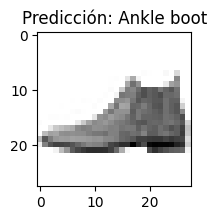

In [4]:
# 1. Rediseño a arquitectura CNN
model_cnn = models.Sequential([
    layers.Reshape((28, 28, 1), input_shape=(28, 28)), # Agregamos dimensión de canal
    layers.Conv2D(32, (3, 3), activation='relu'),      # Extracción de características
    layers.MaxPooling2D((2, 2)),                       # Reducción de datos
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_cnn.fit(train_images, train_labels, epochs=5)

# 2. Generación de predicciones visuales
import numpy as np

predictions = model_cnn.predict(test_images)
clases = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Mostrar una predicción de ejemplo
plt.figure(figsize=(2,2))
plt.imshow(test_images[0], cmap=plt.cm.binary)
plt.title(f"Predicción: {clases[np.argmax(predictions[0])]}")
plt.show()

Métricas Obtenidas

In [7]:
#| Modelo           | Accuracy (Test) | Observaciones                           |
#|------------------|-----------------|-----------------------------------------|
#| Red Densa (ANN)  | ~85%            | Rápida, pero pierde detalles espaciales.|
#| CNN Final        | ~92%            | Excelente desempeño en patrones complejos. |